In [1]:
from functools import partial

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import optimize
from scipy.ndimage import convolve
from tqdm import tqdm

from spectrumlab.backgrounds.asymmetric_least_squares_background.model import AsymmetricLeastSquaresBackgroundConfig, AsymmetricLeastSquaresBackgroundModel, build_mask
from spectrumlab.backgrounds.asymmetric_least_squares_background.utils import estimate_background
from spectrumlab.detectors import Detector
from spectrumlab.noises import ConstantNoise
from spectrumlab.peaks.analyte_peaks.shapes import PeakShape
from spectrumlab.peaks.analyte_peaks.shapes.retrieve_shape import retrieve_shape_from_spectrum
from spectrumlab.peaks.blink_peaks import DraftBlinksConfig, draft_blinks
from spectrumlab.picture.colors import COLOR
from spectrumlab.spectra import EmittedSpectrum
from spectrumlab.types import Array, Number, R

from spectrumlab_emulations.apertures import Aperture, RectangularApertureShape
from spectrumlab_emulations.apparatus import Apparatus, VoigtApparatusShape
from spectrumlab_emulations.experiments.spectra_emulation import RandomPeakExperiment, RandomPeakExperimentConfig


In [2]:
N_NUMBERS = 2048
N_FRAMES = 1
N_PEAKS = 0

EXPOSURE = 100

SHAPE = VoigtApparatusShape(
    width=28,
    asymmetry=+0.1,
    ratio=0.1,
)

MU = -1
SIGMA = .5

ALPHA = 0.000


verbose = True
show = True

In [3]:
def transformer(
    intensity: Array[R],
    background: Array[R],
    alpha: float = 0,
) -> Array[R]:
    assert len(intensity) == len(background)

    number = np.arange(len(intensity))
    index_even = number % 2 == 0
    index_odd = number % 2 == 1

    value = intensity.copy() + background.copy()
    value[index_even] = value[index_even] * (1 - alpha/2)
    value[index_odd] = value[index_odd] * (1 + alpha/2)
    return value


In [4]:
detector = Detector.BLPP2000
position = np.random.uniform(0, N_NUMBERS, size=(N_PEAKS,))
intensity = 10**np.random.normal(MU, SIGMA, size=(N_PEAKS,))

experiment = RandomPeakExperiment(
    config=RandomPeakExperimentConfig(
        n_numbers=N_NUMBERS,
        n_frames=N_FRAMES,

        detector=detector,
        apparatus=Apparatus(
            detector=detector,
            shape=SHAPE,
        ),
        aperture=Aperture(
            detector=detector,
            shape=RectangularApertureShape(),
        ),

        exposure=EXPOSURE,
        position=position,
        intensity=intensity,
    ),
)
experiment = experiment.setup(
    # seed=42,
)

In [92]:
# scale = 1
# number = np.arange(N_NUMBERS)


# background_true = np.zeros(N_NUMBERS, dtype=float) + scale*1
# for amplitude, mu, sigma in [
#     (10, 2500, 75/2),
#     (-10/8, 2500-200, 75/1.5),
#     (6, 600, 125/2),
#     (-6/8, 600-200, 125/1.5),
#     (4, 1400, 75/2),
#     (-4/8, 1400-200, 75/1.5),
#     (3, 1700, 200/2),
#     (-3/8, 1700-200, 200/1.5),
# ]:
#     line = scale * amplitude * np.exp(-((number - mu)**2) / (2 * sigma**2))
#     background_true += line


# background_true[background_true<0] = 0

In [104]:
number = np.arange(N_NUMBERS)
background_true = np.ones(N_NUMBERS, dtype=float)

for _ in range(10):
    amplitude = np.random.uniform(0, 10)
    mu = np.random.uniform(0, N_NUMBERS)
    sigma = np.random.uniform(20, 100)

    background_true += amplitude * np.exp(-((number - mu)**2) / (2 * sigma**2))

    shift = sigma * 1.5
    background_true -= (amplitude/4) * np.exp(-((number - (mu - shift))**2) / (2 * (sigma*0.8)**2))

background_true[background_true < 0] = 0


In [105]:
# %matplotlib widget

# model = AsymmetricLeastSquaresBackgroundModel(
#     config=AsymmetricLeastSquaresBackgroundConfig(
#         lam=1e+5,
#         p=1e-3,
#     ),
# )
# background_hat = model.fit(
#     spectrum=spectrum,
# )


In [106]:
# t = 0

# mask = build_mask(
#     spectrum=spectrum,
#     config=DraftBlinksConfig(
#         n_counts_min=4,
#         except_clipped_peak=False,
#         except_sloped_peak=False,
#         except_edges=True,
#         # amplitude_min=.2,
#         noise_level=4,
#     ),
# )
# sum(mask)

In [107]:
# config = AsymmetricLeastSquaresBackgroundConfig(
#     lam=1e+5,
#     p=1e-4,
# )
# background = np.zeros(spectrum.shape)

# mask = build_mask(
#     spectrum=spectrum,
#     config=DraftBlinksConfig(
#         # n_counts_min=4,
#         except_clipped_peak=False,
#         except_sloped_peak=False,
#         except_edges=True,
#         noise_level=4,
#     ),
# )
# background_hat_v0 = estimate_background(
#     intensity=spectrum.intensity,
#     mask=mask,
#     config=AsymmetricLeastSquaresBackgroundConfig(
#         lam=config.lam,
#         p=config.p,
#     ),
# )

# mask = build_mask(
#     spectrum=spectrum.__class__(
#         intensity=spectrum.intensity - background_hat_v0,
#     ),
#     config=DraftBlinksConfig(
#         n_counts_min=4,
#         except_clipped_peak=False,
#         except_sloped_peak=False,
#         except_edges=False,
#         noise_level=4,
#     ),
# )

# is_outlier = np.full(spectrum.shape, False)
# is_outlier[mask] = spectrum.intensity[mask] - background_hat_v0[mask] > 10 * spectrum.deviation[mask]
# mask[is_outlier] = False

# background_hat_v1 = estimate_background(
#     intensity=spectrum.intensity,
#     mask=mask,
#     config=AsymmetricLeastSquaresBackgroundConfig(
#         lam=config.lam,
#         p=config.p,
#     ),
# )


In [112]:
N_PEAKS = 200

In [113]:
detector = Detector.BLPP2000
position = np.random.uniform(0, N_NUMBERS, size=(N_PEAKS,))
intensity = 10**np.random.normal(MU, SIGMA, size=(N_PEAKS,))

experiment = RandomPeakExperiment(
    config=RandomPeakExperimentConfig(
        n_numbers=N_NUMBERS,
        n_frames=N_FRAMES,

        detector=detector,
        apparatus=Apparatus(
            detector=detector,
            shape=SHAPE,
        ),
        aperture=Aperture(
            detector=detector,
            shape=RectangularApertureShape(),
        ),

        exposure=EXPOSURE,
        position=position,
        intensity=intensity / 2,
    ),
)
experiment = experiment.setup(
    # seed=42,
)
spectrum = experiment.run(
    is_noised=True,
    transformer=partial(transformer, alpha=ALPHA, background=background_true),
)

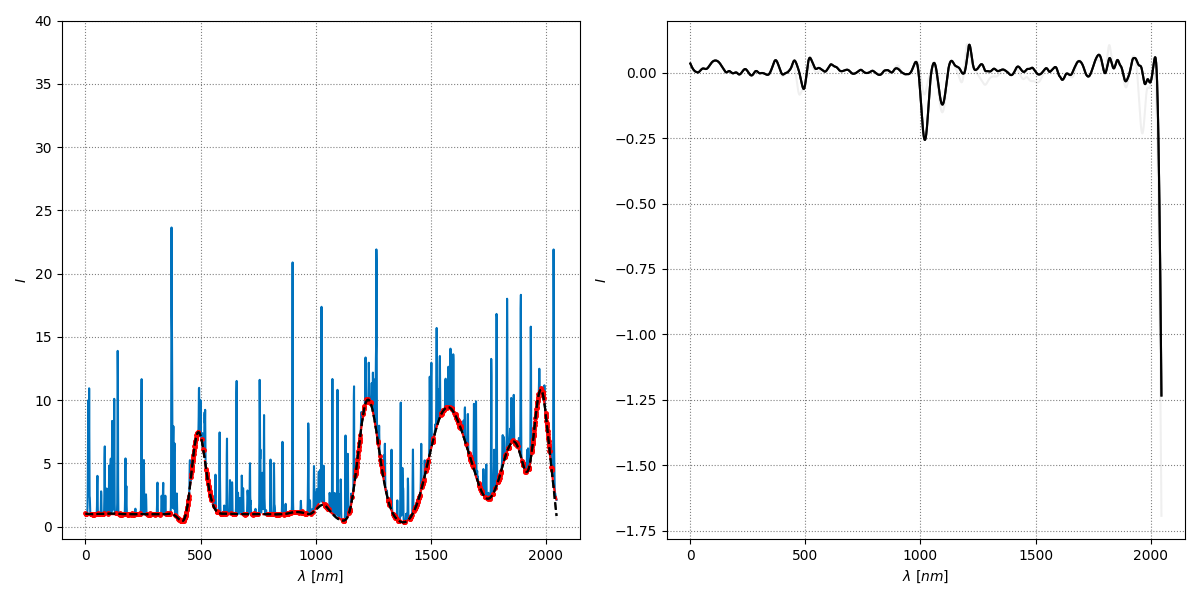

In [114]:
%matplotlib widget

config = DraftBlinksConfig(
    n_counts_min=1,
    except_clipped_peak=False,
    except_sloped_peak=False,
    except_edges=False,
    noise_level=4,
)

is_outlier = np.full(spectrum.shape, False)

background_hat = np.full(spectrum.shape, 0)
background_hats = []
background_hats.append(background_hat)
for _ in range(5):
    mask = build_mask(
        spectrum=spectrum.__class__(
            intensity=spectrum.intensity - background_hats[-1],
            deviation=spectrum.deviation,
        ),
        config=config,
    )
    mask[is_outlier] = False

    background_hat = estimate_background(
        intensity=spectrum.intensity,
        mask=mask,
        config=AsymmetricLeastSquaresBackgroundConfig(
            lam=1e+3,
            p=1e-8,
        ),
    )
    is_outlier[mask] = spectrum.intensity[mask] - background_hat[mask] > 5 * spectrum.deviation[mask]

    background_hats.append(background_hat)


if show:
    fig, (ax_left, ax_right) = plt.subplots(ncols=2, figsize=(12, 6), tight_layout=True)

    ax_left.plot(
        spectrum.wavelength,
        spectrum.intensity,
        color=COLOR['blue'], alpha=1,
    )
    ax_left.plot(
        spectrum.wavelength[mask],
        spectrum.intensity[mask],
        linestyle='none', color='red', alpha=1,
        marker='.', markersize=5,
    )
    ax_left.plot(
        spectrum.wavelength,
        background_true,
        linestyle='--', color='red', alpha=1,
    )
    for i, background_hat in enumerate(background_hats[::-1][:-1]):
        ax_left.plot(
            spectrum.wavelength,
            background_hat,
            linestyle='--', color='black', alpha=(1/2)**(i),
        )
    ax_left.set_ylim([-1, 40])
    ax_left.set_xlabel(r'$\lambda$ [$nm$]')
    ax_left.set_ylabel(r'$I$')
    ax_left.grid(color='grey', linestyle=':')

    for i, background_hat in enumerate(background_hats[::-1][:-1]):
        ax_right.plot(
            spectrum.wavelength,
            background_hat - background_true,
            color='black', alpha=(1/2)**(i),
        )
    ax_right.set_xlabel(r'$\lambda$ [$nm$]')
    ax_right.set_ylabel(r'$I$')
    ax_right.grid(color='grey', linestyle=':')

    plt.show()


In [115]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

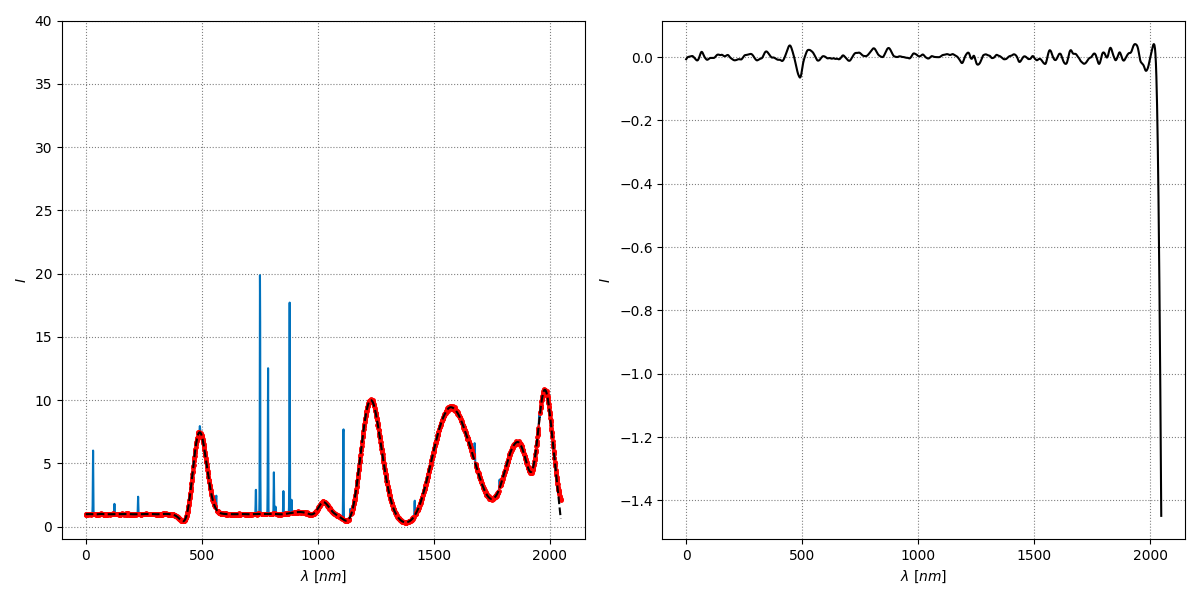

In [ ]:
model = AsymmetricLeastSquaresBackgroundModel(
    config=AsymmetricLeastSquaresBackgroundConfig(
        lam=1e+2,
        p=1e-8,
    ),
)
background_hat = model.fit(
    spectrum=spectrum,
).intensity


if show:
    fig, (ax_left, ax_right) = plt.subplots(ncols=2, figsize=(12, 6), tight_layout=True)

    ax_left.plot(
        spectrum.wavelength,
        spectrum.intensity,
        color=COLOR['blue'], alpha=1,
    )
    ax_left.plot(
        spectrum.wavelength[mask],
        spectrum.intensity[mask],
        linestyle='none', color='red', alpha=1,
        marker='.', markersize=5,
    )
    ax_left.plot(
        spectrum.wavelength,
        background_true,
        linestyle='--', color='red', alpha=1,
    )
    ax_left.plot(
        spectrum.wavelength,
        background_hat,
        linestyle='--', color='black', alpha=1,
    )
    ax_left.set_ylim([-1, 40])
    ax_left.set_xlabel(r'$\lambda$ [$nm$]')
    ax_left.set_ylabel(r'$I$')
    ax_left.grid(color='grey', linestyle=':')

    ax_right.plot(
        spectrum.wavelength,
        background_hat - background_true,
        color='black', alpha=1,
    )
    ax_right.set_xlabel(r'$\lambda$ [$nm$]')
    ax_right.set_ylabel(r'$I$')
    ax_right.grid(color='grey', linestyle=':')

    plt.show()
